# 08 – SHAP Feature Importance Analysis

XGBoost (Tuned) is used here as it was the best-performing model overall (F1: 0.4893, ROC-AUC: 0.6688). This notebook shifts focus from *how well* the model predicts churn to *why* — identifying which customer attributes drive churn predictions.

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction. `TreeExplainer` works efficiently with XGBoost's tree structure for exact SHAP computation. SHAP values are computed on a representative sample of 1,000 test customers. This addresses **RQ3**: *Which customer features have the greatest influence on churn prediction, and what do they reveal about the drivers of customer churn?*

**Inputs:** Preprocessed features from Notebook 02 · Tuned XGBoost hyperparameters from Notebook 06

## Imports

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


## Load Processed Data

Preprocessed features and binary target labels loaded from Notebook 02 outputs. Feature names are recovered from the saved preprocessing pipeline and feature selector, then applied to the processed dataframe so all plots show readable column labels.

In [2]:
import joblib
from sklearn.feature_selection import VarianceThreshold

X_raw_num = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

# Recover feature names from saved pipeline + selector
pipeline  = joblib.load(BASE_DIR / "models" / "preprocessing_pipeline.joblib")
selector  = joblib.load(BASE_DIR / "models" / "feature_selector.joblib")

raw_data  = pd.read_csv(BASE_DIR / "data" / "raw" / "cell2celltrain.csv")
raw_data  = raw_data.replace("Unknown", np.nan)
X_input   = raw_data.drop(columns=["CustomerID", "ServiceArea", "Churn"], errors="ignore")

transformed      = pipeline.transform(X_input)
names_99         = pipeline.get_feature_names_out()
vt               = VarianceThreshold()
vt.fit(transformed)
names_98         = names_99[vt.get_support()]
feature_names    = names_98[selector.get_support()]

# Clean up prefixes (num__, cat__) for readable labels
feature_names_clean = [n.replace("num__", "").replace("cat__", "") for n in feature_names]

X = X_raw_num.copy()
X.columns = feature_names_clean

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)
print("Sample columns:", list(X.columns[:5]))

Features shape: (51047, 50)
Target shape:   (51047,)
Sample columns: ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes']


## Train–Test Split

Same 80/20 stratified split with `random_state=42` as all previous notebooks, ensuring the test set is identical and results are directly comparable.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (40837, 50)
Test set:     (10210, 50)


## Train Tuned XGBoost

The tuned XGBoost is retrained using the best hyperparameters identified in Notebook 06. Under-sampling is applied inside the `ImbPipeline` consistent with all previous notebooks.

In [4]:
pipe_xgb = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=1.0,
        gamma=1.0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

pipe_xgb.fit(X_train, y_train)

best_xgb_pipe = pipe_xgb
best_xgb = pipe_xgb.named_steps["model"]

y_pred = best_xgb_pipe.predict(X_test)
y_prob = best_xgb_pipe.predict_proba(X_test)[:, 1]

print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

F1-score : 0.4893
ROC-AUC  : 0.6688


## SHAP Values — TreeExplainer

`shap.TreeExplainer` exploits XGBoost's tree structure for exact SHAP computation. SHAP values are computed on a stratified sample of 1,000 test customers — representative of the full test set and significantly faster than running on all 10,210 samples. Each value quantifies how much a feature pushed a prediction towards or away from churn relative to the average prediction.

In [5]:
explainer = shap.TreeExplainer(best_xgb)

# Stratified subsample of 1,000 test customers — representative and much faster than full test set
from sklearn.model_selection import train_test_split as tts
X_shap, _, y_shap, _ = tts(X_test, y_test, train_size=1000, stratify=y_test, random_state=42)

shap_values = explainer.shap_values(X_shap)

# XGBoost TreeExplainer returns a 2D array (n_samples, n_features) directly for binary classification
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_churn = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]
elif isinstance(shap_values, list):
    shap_churn = shap_values[1]
    expected_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
else:
    shap_churn = shap_values
    expected_value = explainer.expected_value

print("SHAP values shape:", shap_churn.shape)

mean_abs_shap = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP|:")
print(mean_abs_shap.head(10).to_string())

SHAP values shape: (1000, 50)

Top 10 features by mean |SHAP|:
CurrentEquipmentDays    0.291812
MonthsInService         0.170070
MonthlyMinutes          0.121445
PercChangeMinutes       0.115086
UniqueSubs              0.081156
OverageMinutes          0.076991
TotalRecurringCharge    0.074980
DroppedCalls            0.063362
CreditRating_5-Low      0.061810
AgeHH1                  0.057397


## Beeswarm Plot — Global Feature Importance

Each dot is one test customer for one feature. Position on the x-axis shows the direction and magnitude of the SHAP value — positive means the feature pushed that customer's prediction towards churn. Colour shows the original feature value (red = high, blue = low). Features are ranked by mean absolute SHAP value so the most influential appear at the top.

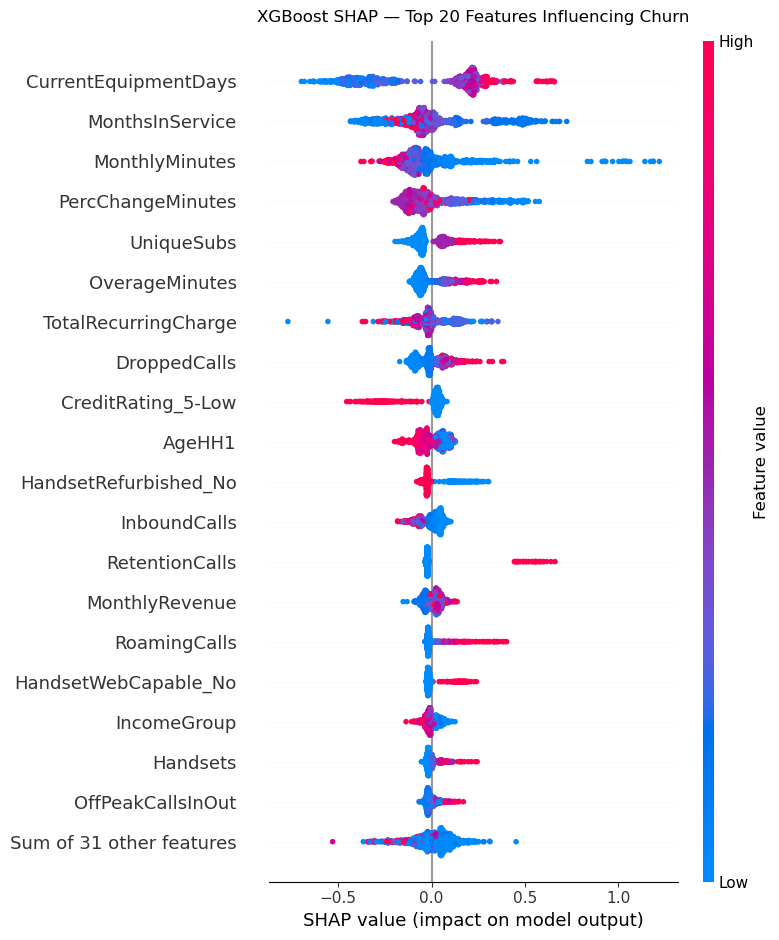

In [6]:
shap_explanation = shap.Explanation(
    values=shap_churn,
    base_values=expected_value,
    data=X_shap.values,
    feature_names=list(X_shap.columns)
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("XGBoost SHAP — Top 20 Features Influencing Churn", pad=14)
plt.tight_layout()
plt.show()

## Bar Plot — Mean Absolute SHAP (Top 15)

Ranks features by their average impact on predictions across all test customers. This is the clearest summary of which features matter most for churn prediction.

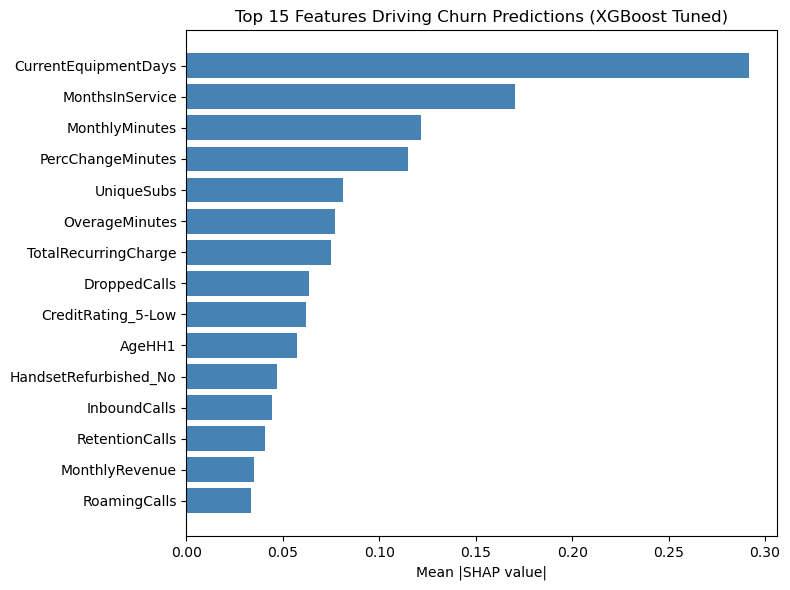

In [7]:
top15 = mean_abs_shap.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color="steelblue")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 Features Driving Churn Predictions (XGBoost Tuned)")
plt.tight_layout()
plt.show()

## Waterfall Plots — Individual Customer Examples

Waterfall plots show how each feature contributed to the prediction for a single customer. One correctly predicted churner and one correctly predicted non-churner are shown to illustrate how the global patterns manifest in individual decisions.

Churner example     : sample index 8
Non-churner example : sample index 1


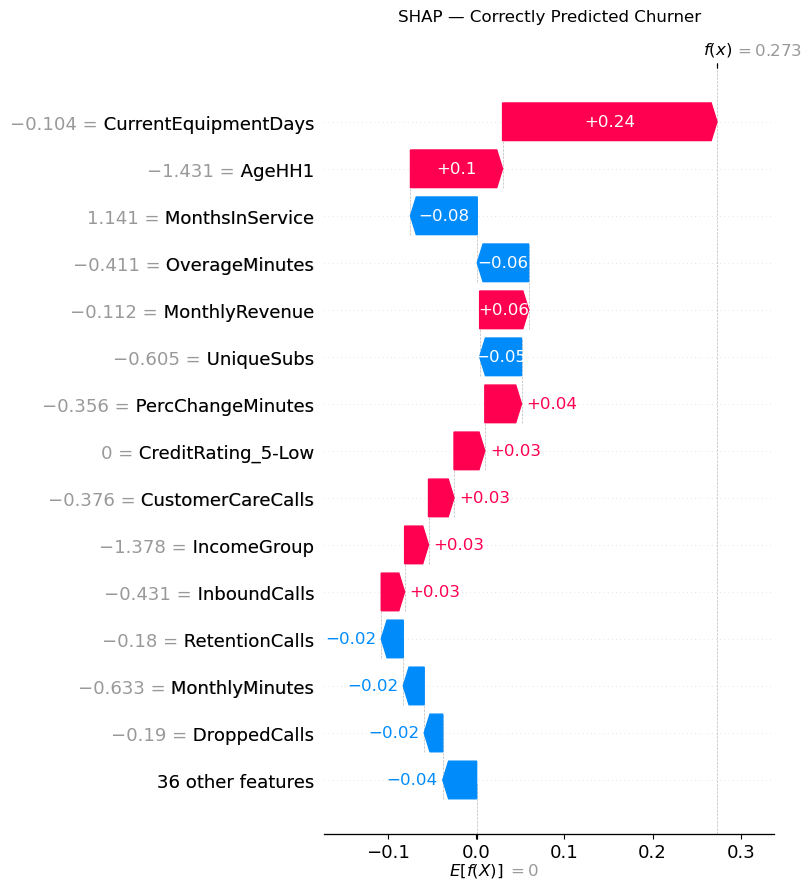

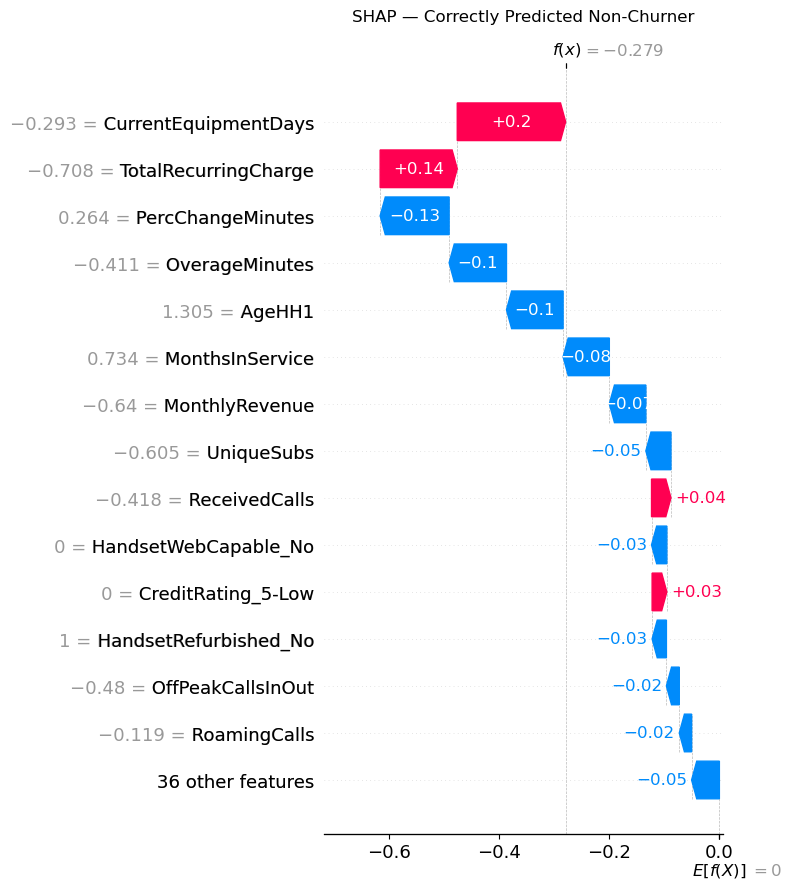

In [8]:
y_pred_shap = best_xgb_pipe.predict(X_shap)
y_shap_arr  = y_shap.values

churner_idx    = np.where((y_shap_arr == 1) & (y_pred_shap == 1))[0][0]
nonchurner_idx = np.where((y_shap_arr == 0) & (y_pred_shap == 0))[0][0]

print(f"Churner example     : sample index {churner_idx}")
print(f"Non-churner example : sample index {nonchurner_idx}")

plt.figure()
shap.plots.waterfall(shap_explanation[churner_idx], max_display=15, show=False)
plt.title("SHAP — Correctly Predicted Churner", pad=14)
plt.tight_layout()
plt.show()

plt.figure()
shap.plots.waterfall(shap_explanation[nonchurner_idx], max_display=15, show=False)
plt.title("SHAP — Correctly Predicted Non-Churner", pad=14)
plt.tight_layout()
plt.show()

## Key Churn Drivers — Discussion (RQ3)

SHAP analysis applied to XGBoost (Tuned) on 1,000 stratified test customers reveals the following top drivers of churn prediction:

**Top 10 features by mean |SHAP value|:**

| Rank | Feature | Mean |SHAP| | Interpretation |
|---|---|---|---|
| 1 | CurrentEquipmentDays | 0.2918 | Strongest predictor — customers with older equipment are actively looking to upgrade, often by switching provider |
| 2 | MonthsInService | 0.1701 | Newer customers churn significantly more; longer tenure correlates with loyalty |
| 3 | MonthlyMinutes | 0.1214 | Both unusually high and low usage flag at-risk customers |
| 4 | PercChangeMinutes | 0.1151 | Sharp changes in usage volume signal dissatisfaction or an impending departure |
| 5 | UniqueSubs | 0.0812 | Number of unique subscribers on the account influences churn behaviour |
| 6 | OverageMinutes | 0.0770 | High overage usage indicates billing pain points beyond the customer's plan |
| 7 | TotalRecurringCharge | 0.0750 | Higher monthly charges are a consistent churn driver — billing friction |
| 8 | DroppedCalls | 0.0634 | Poor call quality drives dissatisfaction and churn |
| 9 | CreditRating_5-Low | 0.0618 | Customers with low credit ratings show elevated churn risk |
| 10 | AgeHH1 | 0.0574 | Household age composition influences churn likelihood |

**Key patterns:**

- **Equipment age** (`CurrentEquipmentDays`) is by far the single strongest predictor — customers with ageing devices are actively looking to upgrade, often by switching provider. This is a clear, actionable signal.
- **Service tenure** (`MonthsInService`) confirms that early-lifecycle customers are the highest risk group; the first year of service is the most critical retention window.
- **Usage and billing signals** (`MonthlyMinutes`, `PercChangeMinutes`, `OverageMinutes`, `TotalRecurringCharge`) consistently appear — unexpected charges and usage shifts are reliable indicators of dissatisfaction.
- **Service quality** (`DroppedCalls`) also features — customers experiencing poor call reliability are more likely to churn.

**Business implication:** Retention efforts should prioritise customers with equipment over 2 years old, customers in their first year of service, customers with high overage or recurring charges, and those experiencing frequent dropped calls — these are the highest-signal indicators of imminent churn.